In [22]:
import pandas as pd
import numpy as np
from pandas.api.types import is_string_dtype

In [23]:
df = pd.read_csv(r"C:\Users\AadharJain\Desktop\IBM_Training-main\DAY_3\zomato.csv", encoding="latin-1")
df.head(2)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591


**Task 1: Intelligent Data Cleaning Pipeline**

In [24]:
def clean_zomato(df):
    
    # removing duplicates
    df = df.drop_duplicates()
            
    # columns to titlecase
    df.columns = df.columns.str.title()
    
    # handling na values
    default_date = pd.Timestamp('2027-01-01')
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col].fillna(0, inplace=True)
        elif pd.api.types.is_string_dtype(df[col]):
            df[col].fillna('', inplace=True)
        elif pd.api.types.is_bool_dtype(df[col]):
            df[col].fillna(False, inplace=True)
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col].fillna(default_date, inplace=True)


    # Function to check if a column only contains 'yes' and 'no'
    def is_yes_no_column(col):
        unique_vals = set(col.dropna().unique())
        return unique_vals.issubset({'Yes', 'No'})
    

    # Apply mapping only to 'yes'/'no' columns
    for col in df.columns:
        if is_yes_no_column(df[col]):
            df[col] = df[col].map({'Yes': 1, 'No': 0})

    # handling impossible values
    numeric_cols = df.select_dtypes(include='number').columns
    df = df[(df[numeric_cols] >= 0).all(axis=1)]
    df = df[(df['Aggregate Rating'] >= 0) & (df['Aggregate Rating'] <= 5.0)]

    return df    
    

In [25]:
df = clean_zomato(df)

C:\Users\AadharJain\AppData\Local\Temp\ipykernel_19332\3815265652.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(0, inplace=True)
C:\Users\AadharJain\AppData\Local\Temp\ipykernel_19332\3815265652.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment usin

**Task 2: Restaurant Popularity Index**


In [26]:
df.columns

Index(['Restaurant Id', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost For Two', 'Currency', 'Has Table Booking',
       'Has Online Delivery', 'Is Delivering Now', 'Switch To Order Menu',
       'Price Range', 'Aggregate Rating', 'Rating Color', 'Rating Text',
       'Votes'],
      dtype='str')

In [27]:
df['A'] = df['Aggregate Rating'] * 0.5                      # Weighted rating
df['B'] = np.log1p(df['Votes']) * 0.2                       # Weighted log votes
df['C'] = df['Has Table Booking'] * 0.1                     # Weighted table booking
df['D'] = df['Has Online Delivery'] * 0.2                   # Weighted online delivery

df['Popularity_Raw'] = df['A'] + df['B'] + df['C'] + df['D']

# Normalize to 0-10 scale
max_raw = df['Popularity_Raw'].max()
df['Popularity_Score'] = (df['Popularity_Raw'] / max_raw) * 10

In [28]:
df.drop(columns=['A','B','C','D','Popularity_Raw'], inplace=True)
df.columns

Index(['Restaurant Id', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost For Two', 'Currency', 'Has Table Booking',
       'Has Online Delivery', 'Is Delivering Now', 'Switch To Order Menu',
       'Price Range', 'Aggregate Rating', 'Rating Color', 'Rating Text',
       'Votes', 'Popularity_Score'],
      dtype='str')

In [29]:
df[['Has Table Booking', 'Has Online Delivery','Aggregate Rating','Votes', 'Popularity_Score']]

,Has Table Booking,Has Online Delivery,Aggregate Rating,Votes,Popularity_Score
0,1,0,4.8,314,8.324406
1,1,0,4.5,591,8.270104
2,1,0,4.4,270,7.799721
3,0,0,4.9,365,8.278827
4,1,0,4.8,229,8.180976
...,...,...,...,...,...
9546,0,0,4.1,788,7.717012
9547,0,0,4.2,1034,7.954802
9548,0,0,3.7,661,7.180905
9549,0,0,4.0,901,7.664039


Which city has the highest average rating?
Which city has the highest average restaurant cost?
Which cuisine receives the highest ratings?
Does online delivery improve ratings?

In [46]:
City_with_highest_rating = df.groupby('City')['Aggregate Rating'].mean().sort_values(ascending=False).head(1)
City_with_highest_cost = df.groupby('City')['Average Cost For Two'].mean().sort_values(ascending=False).head(1)
cuisines_with_highest_rating = df.groupby('Cuisines')['Aggregate Rating'].mean().sort_values(ascending=False).head()


In [78]:
d = {}
for i in range(df.shape[0]):
    cuisines = df.iloc[i]['Cuisines']
    items = cuisines.split(',')
    for item in items:
        item = item.strip()
        rating = df.iloc[i]['Aggregate Rating']
      
        if item not in d:
            d[item] = [rating]
        else:
            d[item].append(rating)
            
avg_rating = {cuisine: sum(rates)/len(rates) for cuisine, rates in d.items()}
sorted_avg_rating = dict(sorted(avg_rating.items(), key=lambda item: item[1], reverse=True))

In [86]:
sorted_avg_rating

{'Bar Food': np.float64(4.9),
 'Bí_rek': np.float64(4.7),
 'Persian': np.float64(4.6),
 'Filipino': np.float64(4.433333333333334),
 'Dí_ner': np.float64(4.4),
 'Kebab': np.float64(4.380000000000001),
 'Izgara': np.float64(4.35),
 'Turkish Pizza': np.float64(4.325),
 'World Cuisine': np.float64(4.3),
 'Modern Indian': np.float64(4.28125),
 'International': np.float64(4.2),
 'Charcoal Grill': np.float64(4.175000000000001),
 'Parsi': np.float64(4.1),
 'Iranian': np.float64(4.066666666666666),
 'Indonesian': np.float64(4.057142857142858),
 'Burmese': np.float64(4.05),
 'Restaurant Cafe': np.float64(4.025),
 'Steak': np.float64(4.0),
 'Goan': np.float64(3.97),
 'Middle Eastern': np.float64(3.9555555555555557),
 'Mediterranean': np.float64(3.937634408602152),
 'German': np.float64(3.9333333333333336),
 'Spanish': np.float64(3.925),
 'Indian': np.float64(3.91904761904762),
 'Cantonese': np.float64(3.9),
 'Dim Sum': np.float64(3.9),
 'Belgian': np.float64(3.9),
 'British': np.float64(3.9),
 'S

In [85]:
first_key = next(iter(sorted_avg_rating))
first_value = sorted_avg_rating[first_key]

print(f"Top rated Cuisine: {first_key},       rating: {first_value}")

Top rated Cuisine: Bar Food,       rating: 4.9


**Does online delivery improve ratings?**

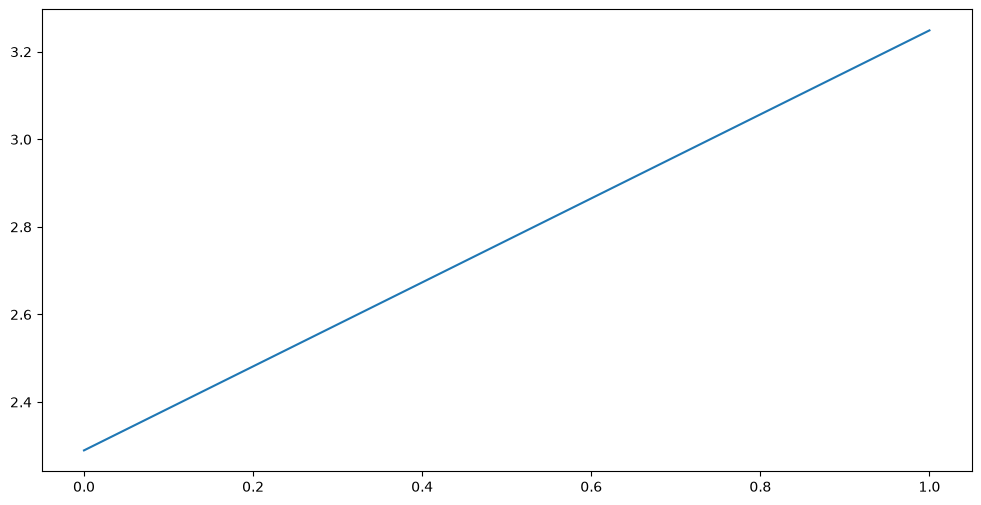

In [88]:
import matplotlib.pyplot as plt
delivery_impact = df.groupby("Has Online Delivery")['Aggregate Rating'].mean()
plt.figure(figsize=(12,6))
plt.plot(delivery_impact)
plt.show()